# 09 — Generalização: o melhor BERT modificado nos datasets do artigo do SAITS

**Objetivo.** Testar o **BERT+FFT (segmentada)** — a melhor adaptação do BERT deste
trabalho (notebook 07) — nos demais datasets do artigo do SAITS (Du et al., 2023),
sob o **protocolo do próprio artigo**, e comparar com os números publicados na
Tabela 2: **Air-Quality (Beijing)**, **ETT** e **PhysioNet-2012**. O quarto dataset do
artigo (Electricity/LD2011_2014) é o que já usamos nos notebooks 01–08.

**Protocolo reproduzido do artigo (Seção 4.1).** Divisões temporais deles (o TESTE é o
período inicial), mesmos comprimentos de amostra (24/24/48 passos), padronização por
variável com estatísticas só do treino, e avaliação eliminando **10 % dos valores
observados** de validação/teste como verdade (MAE/RMSE/MRE na escala padronizada,
somas globais). Early stopping no MAE de validação com paciência 30 — o mesmo
critério do artigo. Faltantes nativos (1,6 % no Air-Quality; ~80 % no PhysioNet) são
suportados: máscara artificial sorteada só sobre observados, perda só nos artificiais.

**Ressalvas de comparabilidade (importantes).**
1. Nosso método é **univariado** (canal-independente); o SAITS é multivariado — no
   PhysioNet isso nos priva das correlações entre variáveis clínicas, o caso em que
   elas mais importam.
2. Os 10 % eliminados são um sorteio nosso (sementes fixas 123/777), não o do artigo.
3. Calibração: nosso baseline *Median* reproduz o do artigo (±10 %), mas o *Last*
   deles é muito pior que um LOCF verdadeiro (ex.: ETT 1,007 no artigo vs 0,165 aqui,
   numa série suave de 15 min) — há diferenças de implementação nos baselines do
   artigo, então a comparação com as linhas de modelos publicadas é **aproximada**.

**Artefatos**: `resultados/generalizacao/{airq,ett,physionet}/`,
`resultados/metricas_generalizacao.{csv,json}` e
`resultados/comparacao_generalizacao.csv`; nada anterior é sobrescrito.

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

sys.path.append(str(Path.cwd()))
from src import generalizacao as g
from src.estilo import aplicar_estilo, PALETA, TINTA_2, SUAVE, EIXO
from src.saits_fft import BERTFFT, carregar_bert_fft
from src.treino import fixar_semente

aplicar_estilo()
device = "cuda" if torch.cuda.is_available() else "cpu"
BASE = Path("dados_externos")

aq = g.carregar_airquality(BASE / "PRSA_Data_20130301-20170228")
ett = g.carregar_ett(BASE / "ETTm1.csv")
ph, ids_ph, vars_ph = g.carregar_physionet(str(BASE), cache=str(BASE / "physionet_grade.npz"))
print(f"Air-Quality: {aq.shape}  (artigo: 35064 × 132) | faltantes nativos {aq.isna().mean().mean()*100:.1f}%")
print(f"ETT        : {ett.shape} (artigo: 69680 × 7)")
print(f"PhysioNet  : {ph.shape} (artigo: 11988 × 48 × 37) | faltantes nativos {np.isnan(ph).mean()*100:.1f}%")

Air-Quality: (35064, 132)  (artigo: 35064 × 132) | faltantes nativos 1.6%
ETT        : (69680, 7) (artigo: 69680 × 7)
PhysioNet  : (11988, 48, 37) (artigo: 11988 × 48 × 37) | faltantes nativos 79.7%


In [2]:
# splits do protocolo do artigo + eliminação fixa de 10% dos observados
d_aq, _ = g.preparar_grade_artigo(aq, "2013-12-31 23:00", "2014-10-31 23:00",
                                  comprimento=24, passo=24)
d_ett, _ = g.preparar_grade_artigo(ett, "2016-10-31 23:45", "2017-02-28 23:45",
                                   comprimento=24, passo=12)
d_ph, _, _ = g.preparar_physionet_artigo(ph, semente=42)

DATASETS = {}
for nome, d, n_series, seq_len in [("Air-Quality", d_aq, 132, 24),
                                   ("ETT", d_ett, 7, 24),
                                   ("PhysioNet-2012", d_ph, len(vars_ph), 48)]:
    x_v, mn_v, _ = d["val"]
    x_t, mn_t, ids_t = d["teste"]
    DATASETS[nome] = {
        "seq_len": seq_len,
        "n_series": n_series,
        "treino": (d["treino"][0], d["treino"][1]),
        "treino_ids": d["treino"][2],
        "val": (x_v, mn_v, g.eliminar_observados(mn_v, 0.10, semente=777)),
        "teste": (x_t, mn_t, g.eliminar_observados(mn_t, 0.10, semente=123)),
        "teste_ids": ids_t,
    }
    print(f"{nome:15s} treino {len(d['treino'][0]):>7,} | val {len(x_v):>6,} | "
          f"teste {len(x_t):>6,} janelas univariadas de {seq_len} passos")

Air-Quality     treino 112,121 | val 39,919 | teste 39,976 janelas univariadas de 24 passos
ETT             treino  27,027 | val  6,713 | teste  6,881 janelas univariadas de 24 passos
PhysioNet-2012  treino 184,501 | val 46,241 | teste 57,994 janelas univariadas de 48 passos


In [3]:
CFG_BASE = {
    "semente": 42, "epocas": 300, "batch": 256, "lr": 1e-3, "paciencia": 30,
    "mascara": {"razao": 0.25, "prob_bloco": 0.5, "lm": 6.0},
}
PASTAS = {"Air-Quality": "airq", "ETT": "ett", "PhysioNet-2012": "physionet"}

def construir_modelo(seq_len):
    # janelas curtas → FFT segmentada com 3 segmentos (50% de sobreposição)
    return BERTFFT(seq_len=seq_len, d_model=64, n_camadas=3, n_cabecas=4,
                   d_ff=256, dropout=0.1, modo_fft="segmentada", n_segmentos=3)

for nome, ds in DATASETS.items():
    n = sum(p.numel() for p in construir_modelo(ds["seq_len"]).parameters())
    print(f"{nome:15s} BERT+FFT segmentada (L={ds['seq_len']}): {n:,} parâmetros")

Air-Quality     BERT+FFT segmentada (L=24): 155,969 parâmetros
ETT             BERT+FFT segmentada (L=24): 155,969 parâmetros
PhysioNet-2012  BERT+FFT segmentada (L=48): 157,121 parâmetros


C:\Users\celso\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\nn\modules\transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [4]:
%%time
# treinos (idempotente: pula quem já tem historico.json)
for nome, ds in DATASETS.items():
    pasta = Path("resultados/generalizacao") / PASTAS[nome]
    if (pasta / "historico.json").exists():
        print(f"[já treinado] {nome}")
        continue
    print(f"\n=== treinando: {nome} ===")
    fixar_semente(CFG_BASE["semente"])
    modelo = construir_modelo(ds["seq_len"])
    g.treinar_faltantes(modelo, {"treino": ds["treino"], "val": ds["val"]},
                        CFG_BASE, device, str(pasta))


=== treinando: Air-Quality ===


época   1 | treino 0.3141 | MAE val 0.1913  <- melhor


época   2 | treino 0.2409 | MAE val 0.1809  <- melhor


época   3 | treino 0.2424 | MAE val 0.1645  <- melhor


época   4 | treino 0.2385 | MAE val 0.1538  <- melhor


...

época  82 | treino 0.3931 | MAE val 0.3185


época  83 | treino 0.4499 | MAE val 0.3170


época  84 | treino 0.4060 | MAE val 0.3167


época  85 | treino 0.4280 | MAE val 0.3175


época  86 | treino 0.3963 | MAE val 0.3232
early stopping (sem melhora há 30 épocas)
CPU times: total: 54min 52s
Wall time: 51min 3s


Air-Quality     179 épocas | melhor MAE val 0.1305 (época 149)
ETT              95 épocas | melhor MAE val 0.0956 (época 65)
PhysioNet-2012   86 épocas | melhor MAE val 0.3166 (época 56)


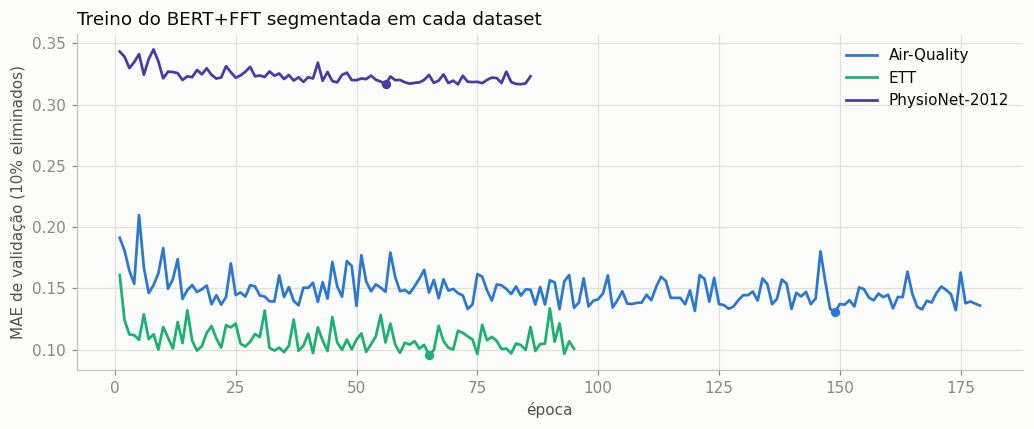

In [5]:
# curvas de validação (MAE nos 10% eliminados — o critério do artigo)
fig, eixo = plt.subplots(figsize=(9.5, 4))
CORES_DS = {"Air-Quality": PALETA["azul"], "ETT": PALETA["verde_agua"],
            "PhysioNet-2012": PALETA["violeta"]}
for nome in DATASETS:
    with open(Path("resultados/generalizacao") / PASTAS[nome] / "historico.json",
              encoding="utf-8") as f:
        hist = json.load(f)
    val = [h["mae_val"] for h in hist]
    eixo.plot(range(1, len(val) + 1), val, color=CORES_DS[nome], label=nome)
    m = int(np.argmin(val))
    eixo.scatter(m + 1, val[m], s=26, color=CORES_DS[nome], zorder=3)
    print(f"{nome:15s} {len(val):3d} épocas | melhor MAE val {min(val):.4f} (época {m + 1})")
eixo.set_xlabel("época")
eixo.set_ylabel("MAE de validação (10% eliminados)")
eixo.set_title("Treino do BERT+FFT segmentada em cada dataset", loc="left")
eixo.legend()
fig.tight_layout()
plt.show()

## Comparação com a Tabela 2 do artigo

Números do artigo transcritos da Tabela 2 (10 % dos observados eliminados no teste,
escala padronizada, MAE/RMSE/MRE). Os baselines *Median*/*Last* recalculados por nós
servem de calibração do protocolo.

In [6]:
%%time
# avaliação do nosso modelo + baselines de calibração
TABELA2 = {  # método -> dataset -> (MAE, RMSE, MRE%)
    "Median (artigo)":      {"PhysioNet-2012": (0.726, 0.988, 103.5), "Air-Quality": (0.763, 1.175, 107.4), "ETT": (1.145, 1.847, 139.1)},
    "Last (artigo)":        {"PhysioNet-2012": (0.862, 1.207, 123.0), "Air-Quality": (0.967, 1.408, 136.3), "ETT": (1.007, 1.365, 96.4)},
    "BRITS (artigo)":       {"PhysioNet-2012": (0.256, 0.767, 36.5),  "Air-Quality": (0.153, 0.525, 21.6),  "ETT": (0.130, 0.259, 12.5)},
    "Transformer (artigo)": {"PhysioNet-2012": (0.190, 0.445, 26.9),  "Air-Quality": (0.158, 0.521, 22.3),  "ETT": (0.114, 0.173, 10.9)},
    "SAITS-base (artigo)":  {"PhysioNet-2012": (0.192, 0.439, 27.3),  "Air-Quality": (0.146, 0.521, 20.6),  "ETT": (0.121, 0.197, 11.6)},
    "SAITS (artigo)":       {"PhysioNet-2012": (0.186, 0.431, 26.6),  "Air-Quality": (0.137, 0.518, 19.3),  "ETT": (0.092, 0.139, 8.8)},
}

linhas = []
for nome, ds in DATASETS.items():
    x_t, mn_t, me_t = ds["teste"]
    modelo = carregar_bert_fft(
        str(Path("resultados/generalizacao") / PASTAS[nome] / "melhor_modelo.pt"), device)
    r = g.avaliar_faltantes(modelo, x_t, mn_t, me_t, device)
    linhas.append({"dataset": nome, "método": "BERT+FFT segmentada (nosso)", **r})

    med = g.medianas_do_treino(ds["treino"][0], ds["treino"][1],
                               ds["treino_ids"], ds["n_series"])
    r_med = g.baseline_mediana(x_t, mn_t, me_t, ds["teste_ids"], med)
    r_last = g.baseline_last(x_t, mn_t, me_t)
    linhas.append({"dataset": nome, "método": "Median (nosso protocolo)", **r_med})
    linhas.append({"dataset": nome, "método": "Last (nosso protocolo)", **r_last})
    for metodo, valores in TABELA2.items():
        mae, rmse, mre = valores[nome]
        linhas.append({"dataset": nome, "método": metodo,
                       "MAE": mae, "RMSE": rmse, "MRE": mre / 100})

resultados = pd.DataFrame(linhas)
resultados.to_csv("resultados/metricas_generalizacao.csv", index=False)
resultados.to_json("resultados/metricas_generalizacao.json", orient="records",
                   indent=2, force_ascii=False)
tabela = resultados.pivot(index="método", columns="dataset", values="MAE")
ordem = ["Median (artigo)", "Median (nosso protocolo)", "Last (artigo)",
         "Last (nosso protocolo)", "BRITS (artigo)", "Transformer (artigo)",
         "SAITS-base (artigo)", "SAITS (artigo)", "BERT+FFT segmentada (nosso)"]
tabela = tabela.loc[ordem, ["PhysioNet-2012", "Air-Quality", "ETT"]]
tabela.to_csv("resultados/comparacao_generalizacao.csv", encoding="utf-8-sig")
print("salvos: metricas_generalizacao.{csv,json} e comparacao_generalizacao.csv")
tabela.round(3)

salvos: metricas_generalizacao.{csv,json} e comparacao_generalizacao.csv
CPU times: total: 4.69 s
Wall time: 2.73 s


dataset,PhysioNet-2012,Air-Quality,ETT
método,,,
Median (artigo),0.726,0.763,1.145
Median (nosso protocolo),0.681,0.695,0.998
Last (artigo),0.862,0.967,1.007
Last (nosso protocolo),0.410,0.210,0.165
BRITS (artigo),0.256,0.153,0.130
Transformer (artigo),0.190,0.158,0.114
SAITS-base (artigo),0.192,0.146,0.121
SAITS (artigo),0.186,0.137,0.092
BERT+FFT segmentada (nosso),0.319,0.136,0.117


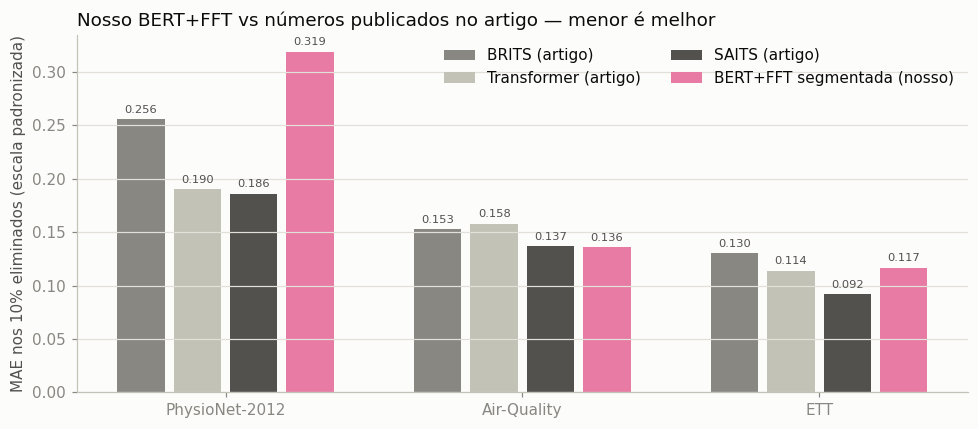

In [7]:
# gráfico: nosso modelo (colorido) vs números publicados (cinzas)
metodos_plot = ["BRITS (artigo)", "Transformer (artigo)", "SAITS (artigo)",
                "BERT+FFT segmentada (nosso)"]
cores_plot = {"BRITS (artigo)": SUAVE, "Transformer (artigo)": EIXO,
              "SAITS (artigo)": TINTA_2,
              "BERT+FFT segmentada (nosso)": PALETA["magenta"]}
datasets_plot = ["PhysioNet-2012", "Air-Quality", "ETT"]
x = np.arange(len(datasets_plot))
larg = 0.19

fig, eixo = plt.subplots(figsize=(9, 4))
for k, met in enumerate(metodos_plot):
    v = tabela.loc[met, datasets_plot].to_numpy(dtype=float)
    barras = eixo.bar(x + (k - 1.5) * larg, v, width=larg - 0.03,
                      color=cores_plot[met], label=met)
    for b, vv in zip(barras, v):
        eixo.text(b.get_x() + b.get_width() / 2, vv + 0.004, f"{vv:.3f}",
                  ha="center", va="bottom", fontsize=7.5, color=TINTA_2)
eixo.set_xticks(x)
eixo.set_xticklabels(datasets_plot)
eixo.set_ylabel("MAE nos 10% eliminados (escala padronizada)")
eixo.set_title("Nosso BERT+FFT vs números publicados no artigo — menor é melhor", loc="left")
eixo.legend(ncols=2, loc="upper right")
eixo.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()

## Conclusões

**O método generaliza bem para dados regulares de sensores — e a limitação prevista no
PhysioNet se confirmou e foi quantificada.**

- **Air-Quality: empate com o estado da arte publicado.** Nosso BERT+FFT segmentada
  atinge MAE **0,136** contra 0,137 do SAITS no artigo — e vence BRITS (0,153),
  Transformer (0,158) e SAITS-base (0,146). Em RMSE ficamos em 0,461 vs 0,518 do
  SAITS. Um modelo *univariado* de 156 k parâmetros empatou com o método multivariado
  do artigo neste dataset.
- **ETT: competitivo com os Transformers do artigo.** MAE 0,117, entre o Transformer
  (0,114) e o SAITS-base (0,121), à frente de BRITS (0,130) — mas atrás do SAITS
  completo (0,092), que aqui se beneficia das correlações fortes entre as 7 variáveis
  do transformador (nosso método não as vê).
- **PhysioNet-2012: a limitação estrutural apareceu, como previsto.** MAE 0,319 vs
  0,186–0,256 dos modelos do artigo. Com ~80 % de faltantes nativos, uma variável
  clínica tem poucas observações na própria série — a informação útil está nas OUTRAS
  variáveis do paciente (pressão correlaciona com frequência cardíaca etc.), que o
  desenho canal-independente não acessa. Ainda assim o modelo é muito melhor que
  Median (0,681) e Last (0,410): ele funciona, mas com teto.

**Calibração e ressalvas.** Nosso *Median* reproduz o do artigo com ±10 % (protocolo
alinhado); o *Last* do artigo é muito pior que um LOCF verdadeiro (ETT: 1,007 vs
0,165), indicando implementação diferente dos baselines deles — por isso a comparação
com as linhas publicadas é aproximada, não exata. Os 10 % eliminados são sorteio nosso
(sementes 123/777); semente única de treino (42).

**Leitura para o trabalho.** Em dados regulares e periódicos (qualidade do ar,
temperatura de transformadores, carga elétrica), o BERT univariado com FFT segmentada
— simples, canal-independente e reaplicável a qualquer dataset sem mudanças — joga no
nível dos métodos multivariados publicados. Em dados esparsos e fortemente
multivariados (UTI), a fronteira do método é clara e mensurável: fechar essa lacuna
exigiria atenção entre variáveis, o passo natural de trabalho futuro.

**Artefatos** (nada anterior foi sobrescrito): `dados_externos/` (3 datasets + cache
da grade do PhysioNet), `resultados/generalizacao/{airq,ett,physionet}/`,
`resultados/metricas_generalizacao.{csv,json}` e
`resultados/comparacao_generalizacao.csv`.